# Detekcija govora mržnje

**NLP task:** Automatska identifikacija govora mržnje u kratkim tekstovima (tweetovi)
**Pristup:** Binarna klasifikacija — legitimni tekst (label 0) vs. govor mržnje (label 1)

Ispitana su dva oblika tekstualne reprezentacije:

1. **TF-IDF** — klasična bag-of-words reprezentacija s n-gramima
2. **Sentence-BERT** — duboka kontekstualna reprezentacija zasnovana na transformerima

Isti klasifikator (logistička regresija s `class_weight='balanced'`) korišten je u oba slučaja kako bi poređenje bilo fer.
Dataset dolazi iz `data/processed/hate_speech_{train,val,test}.csv`.

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = PROJECT_ROOT / 'data' / 'processed'

## Učitavanje podataka

Podaci su podijeljeni stratificiranim splitom (70/15/15) u fazi preprocesiranja.
Dataset kombinuje Davidson et al. (2017) hate speech korpus i `tweet_eval/hate` dataset s
Hugging Face-a, harmonizirane u zajednički binarni label (0 = nije govor mržnje, 1 = govor mržnje).

In [ ]:
train = pd.read_csv(DATA / 'hate_speech_train.csv')
val   = pd.read_csv(DATA / 'hate_speech_val.csv')
test  = pd.read_csv(DATA / 'hate_speech_test.csv')

print(f"Veličina skupova — train: {len(train)}, val: {len(val)}, test: {len(test)}")
print(f"\nRaspodjela klasa (train):")
print(train['label'].value_counts().rename({0: 'not_hate', 1: 'hate'}))
print(f"\nPo izvoru (train):")
print(train.groupby('source')['label'].value_counts())

y_train = train['label']
y_val   = val['label']
y_test  = test['label']

Veličina skupova — train: 26019, val: 5576, test: 5576

Raspodjela klasa (train):
label
not_hate    21320
hate         4699
Name: count, dtype: int64

Po izvoru (train):
source      label
davidson    0        17065
            1         4184
tweet_eval  0         4255
            1          515
Name: count, dtype: int64

## Oblik 1: TF-IDF reprezentacija

Tekst je reprezentovan TF-IDF vektorima (unigrami i bigrami, maksimalno 20 000 feature-a,
`sublinear_tf=True`). Klasifikator je logistička regresija s `class_weight='balanced'`
zbog neravnomjerne raspodjele klasa (~82% not_hate, ~18% hate).
Ulaz je `text_clean` kolona — preprocesirani tekst s placeholder tokenima za URL-ove,
e-mail adrese i telefonske brojeve.

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=20_000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)

X_train_tfidf = vectorizer.fit_transform(train['text_clean'].fillna(''))
X_val_tfidf   = vectorizer.transform(val['text_clean'].fillna(''))
X_test_tfidf  = vectorizer.transform(test['text_clean'].fillna(''))

clf_tfidf = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0, random_state=42)
clf_tfidf.fit(X_train_tfidf, y_train)
print("Treniranje završeno.")

Treniranje završeno.

=== TF-IDF + LR – validacijski skup ===
              precision    recall  f1-score   support

    not_hate       0.94      0.83      0.88      4569
        hate       0.49      0.75      0.59      1007

    accuracy                           0.81      5576
   macro avg       0.71      0.79      0.74      5576
weighted avg       0.86      0.81      0.83      5576


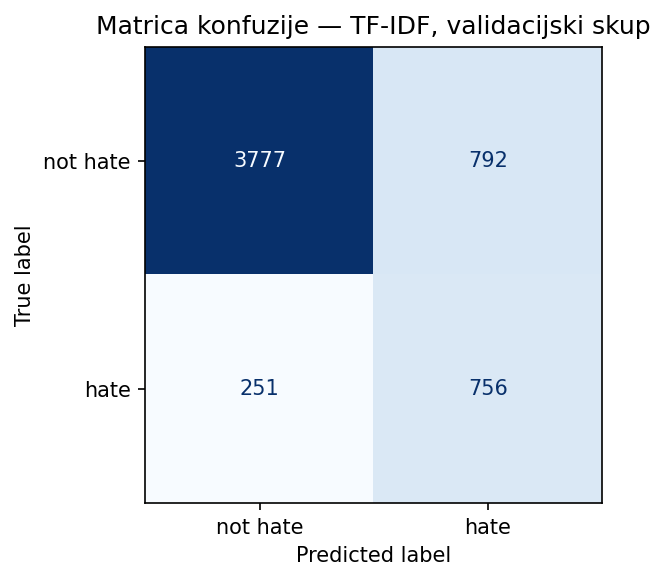

In [ ]:
y_val_pred_tfidf = clf_tfidf.predict(X_val_tfidf)
y_val_prob_tfidf = clf_tfidf.predict_proba(X_val_tfidf)[:, 1]

print("=== TF-IDF + LR – validacijski skup ===")
print(classification_report(y_val, y_val_pred_tfidf, target_names=['not_hate', 'hate']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred_tfidf,
    display_labels=['not hate', 'hate'], ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title('Matrica konfuzije – TF-IDF (validacija)')
plt.tight_layout()
plt.show()

TF-IDF model postiže F1-score **0.59** za hate klasu na validacijskom skupu, uz ukupnu accuracy 0.81.
Recall (0.75) je viši od precision-a (0.49) — model češće lažno uzbunjuje legitimni tekst nego što
propušta stvarni govor mržnje. Ovo je poželjan kompromis u kontekstu moderiranja sadržaja, gdje su
propuštene prevare opasnije od lažnih uzbuna. Precision je relativno nizak, što je karakteristično
za hate speech detection: govor mržnje često dijeli vokabular s legitimnim ali grubim jezikom.

In [ ]:
fpr_tv, tpr_tv, _ = roc_curve(y_val, y_val_prob_tfidf)
auc_tv = roc_auc_score(y_val, y_val_prob_tfidf)

plt.figure()
plt.plot(fpr_tv, tpr_tv, label=f'TF-IDF + LR (AUC = {auc_tv:.4f})')
plt.plot([0, 1], [0, 1], '--', color='grey', alpha=0.5)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC kriva – TF-IDF (validacija)')
plt.legend(); plt.tight_layout(); plt.show()
print(f"ROC-AUC (validacija): {auc_tv:.4f}")

ROC-AUC (validacija): 0.8651

ROC-AUC od **0.8651** na validacijskom skupu ukazuje na solidnu diskriminativnu moć modela —
znatno iznad slučajnog (0.5), ali niže nego kod zadataka poput detekcije spama.
Ovo odražava složenost hate speech detekcije: granica između uvredljivog i nenametljivog govora
nije uvijek leksički jasna.

## Oblik 2: Duboka kontekstualna reprezentacija (Sentence-BERT)

Korišten je model `all-MiniLM-L6-v2` iz `sentence-transformers` biblioteke.
Model svaki tekst mapira u gust 384-dimenzionalni vektor koji kodira semantičko značenje.
Za razliku od TF-IDF-a, BERT razumije kontekst i može prepoznati da dvije različite formulacije
imaju isto (negativno) značenje. Enkodiranje je rađeno nad originalnim tekstom (`text` kolona)
jer BERT-ov tokenizator sam vrši normalizaciju. Isti tip klasifikatora je primijenjen radi
fer poređenja s TF-IDF pristupom.

In [ ]:
from sentence_transformers import SentenceTransformer

sbert = SentenceTransformer('all-MiniLM-L6-v2')

print("Enkodiranje trening skupa...")
E_train = sbert.encode(train['text'].fillna('').tolist(), batch_size=128, show_progress_bar=True)
print("Enkodiranje validacijskog skupa...")
E_val = sbert.encode(val['text'].fillna('').tolist(), batch_size=128, show_progress_bar=True)
print("Enkodiranje testnog skupa...")
E_test = sbert.encode(test['text'].fillna('').tolist(), batch_size=128, show_progress_bar=True)

print(f"\nDimenzija embedding vektora: {E_train.shape[1]}")

Enkodiranje trening skupa...
Enkodiranje validacijskog skupa...
Enkodiranje testnog skupa...

Dimenzija embedding vektora: 384

=== Sentence-BERT + LR – validacijski skup ===
              precision    recall  f1-score   support

    not_hate       0.93      0.76      0.84      4569
        hate       0.41      0.76      0.53      1007

    accuracy                           0.76      5576
   macro avg       0.67      0.76      0.68      5576
weighted avg       0.84      0.76      0.78      5576


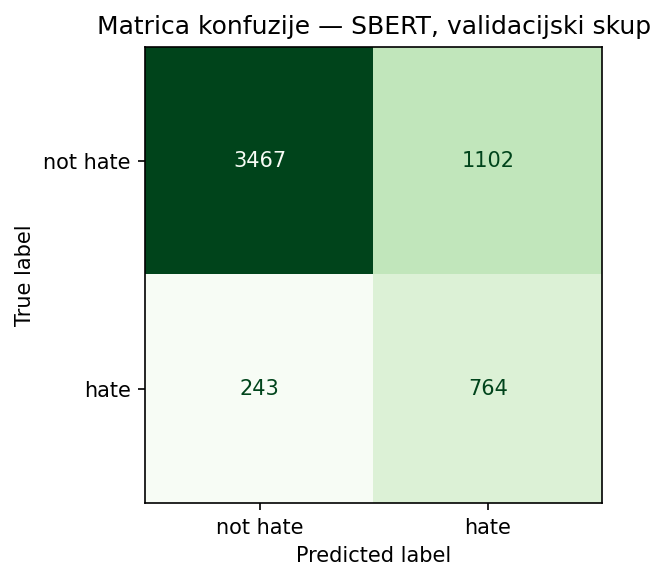

In [ ]:
clf_sbert = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0, random_state=42)
clf_sbert.fit(E_train, y_train)

y_val_pred_sbert = clf_sbert.predict(E_val)
y_val_prob_sbert = clf_sbert.predict_proba(E_val)[:, 1]

print("=== Sentence-BERT + LR – validacijski skup ===")
print(classification_report(y_val, y_val_pred_sbert, target_names=['not_hate', 'hate']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred_sbert,
    display_labels=['not hate', 'hate'], ax=ax, colorbar=False, cmap='Greens'
)
ax.set_title('Matrica konfuzije – Sentence-BERT (validacija)')
plt.tight_layout()
plt.show()

Sentence-BERT postiže recall **0.76** za hate klasu — isti kao TF-IDF — ali s nižim precision-om
(0.41 vs 0.49). Ukupna accuracy je niža (0.76 vs 0.81) jer model proizvodi više lažnih uzbuna.
Na ovom tipu podataka, kontekstualna reprezentacija nije donijela prednost nad TF-IDF-om.

In [ ]:
fpr_sv, tpr_sv, _ = roc_curve(y_val, y_val_prob_sbert)
auc_sv = roc_auc_score(y_val, y_val_prob_sbert)

plt.figure()
plt.plot(fpr_sv, tpr_sv, label=f'Sentence-BERT + LR (AUC = {auc_sv:.4f})')
plt.plot([0, 1], [0, 1], '--', color='grey', alpha=0.5)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC kriva – Sentence-BERT (validacija)')
plt.legend(); plt.tight_layout(); plt.show()
print(f"ROC-AUC (validacija): {auc_sv:.4f}")

ROC-AUC (validacija): 0.8424

## Evaluacija na testnom skupu

Finalna evaluacija rađena je na odvojenom testnom skupu koji nije korišten tokom
treniranja ni podešavanja modela.

In [ ]:
y_test_pred_tfidf = clf_tfidf.predict(X_test_tfidf)
y_test_prob_tfidf = clf_tfidf.predict_proba(X_test_tfidf)[:, 1]

y_test_pred_sbert = clf_sbert.predict(E_test)
y_test_prob_sbert = clf_sbert.predict_proba(E_test)[:, 1]

print("=== TF-IDF + LR – testni skup ===")
print(classification_report(y_test, y_test_pred_tfidf, target_names=['not_hate', 'hate']))

print("=== Sentence-BERT + LR – testni skup ===")
print(classification_report(y_test, y_test_pred_sbert, target_names=['not_hate', 'hate']))

=== TF-IDF + LR – testni skup ===
              precision    recall  f1-score   support

    not_hate       0.93      0.82      0.87      4569
        hate       0.47      0.71      0.56      1007

    accuracy                           0.80      5576
   macro avg       0.70      0.77      0.72      5576
weighted avg       0.84      0.80      0.82      5576

=== Sentence-BERT + LR – testni skup ===
              precision    recall  f1-score   support

    not_hate       0.93      0.75      0.84      4569
        hate       0.41      0.76      0.53      1007

    accuracy                           0.76      5576
   macro avg       0.67      0.76      0.68      5576
weighted avg       0.84      0.76      0.78      5576


Na testnom skupu TF-IDF zadržava prednost: F1 0.56 vs 0.53 za hate klasu, uz bolji AUC (0.847 vs 0.830).
Oba modela su konzistentna između val i test skupova — nema znakova prenapasivanja.
Precision ostaje nizak za oba (0.47 / 0.41), što je karakteristično za hate speech detection
i odražava inherentnu teškoću taska: mnogi legitimni tekstovi koriste slično izražavanje.

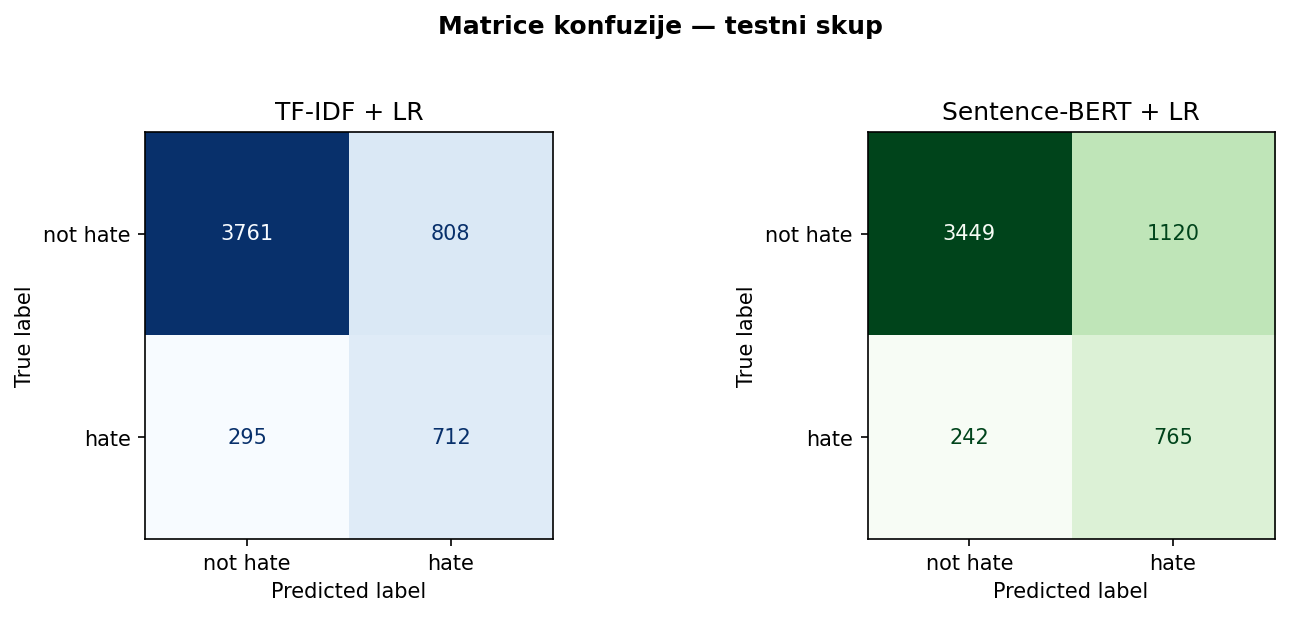

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred_tfidf,
    display_labels=['not hate', 'hate'], ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('TF-IDF + LR')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred_sbert,
    display_labels=['not hate', 'hate'], ax=axes[1], colorbar=False, cmap='Greens'
)
axes[1].set_title('Sentence-BERT + LR')

plt.suptitle('Matrice konfuzije – testni skup', y=1.02)
plt.tight_layout()
plt.show()

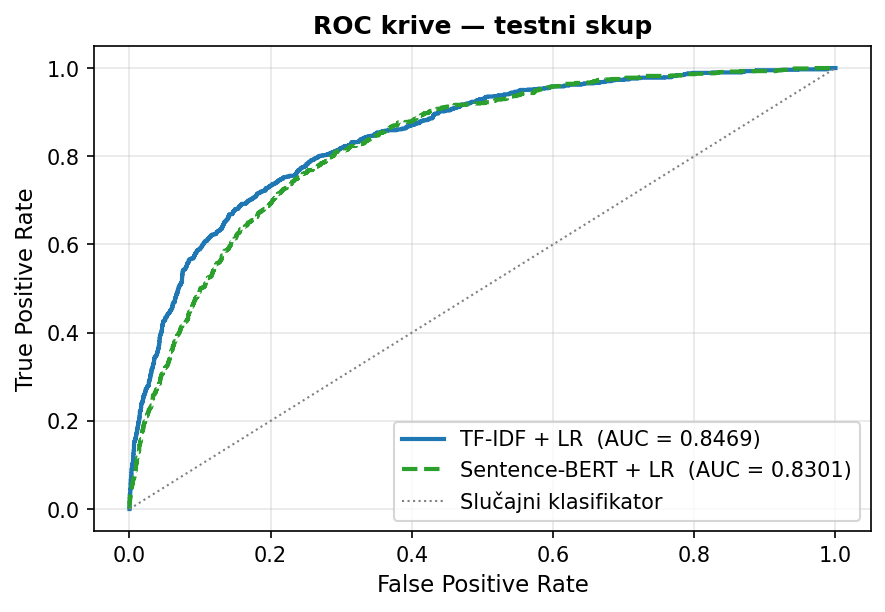

In [ ]:
fpr_t, tpr_t, _ = roc_curve(y_test, y_test_prob_tfidf)
auc_t = roc_auc_score(y_test, y_test_prob_tfidf)
fpr_s, tpr_s, _ = roc_curve(y_test, y_test_prob_sbert)
auc_s = roc_auc_score(y_test, y_test_prob_sbert)

plt.figure(figsize=(7, 5))
plt.plot(fpr_t, tpr_t, label=f'TF-IDF + LR  (AUC = {auc_t:.4f})')
plt.plot(fpr_s, tpr_s, label=f'Sentence-BERT + LR  (AUC = {auc_s:.4f})')
plt.plot([0, 1], [0, 1], '--', color='grey', alpha=0.5)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Poređenje ROC krivih – testni skup')
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
def get_metrics(y_true, y_pred, y_prob, name):
    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision (hate)': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall (hate)': round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1 (hate)': round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(y_true, y_prob), 4),
    }

results = pd.DataFrame([
    get_metrics(y_test, y_test_pred_tfidf, y_test_prob_tfidf, 'TF-IDF + LR'),
    get_metrics(y_test, y_test_pred_sbert, y_test_prob_sbert, 'Sentence-BERT + LR'),
]).set_index('Model')

results

                    Accuracy  Precision (hate)  Recall (hate)  F1 (hate)  ROC-AUC
Model
TF-IDF + LR           0.8022            0.4684         0.7071     0.5635   0.8469
Sentence-BERT + LR    0.7557            0.4058         0.7597     0.5290   0.8301

## Podešavanje praga odluke

Podrazumijevani prag klasifikacije je 0.5 — svaki primjer s P(hate) ≥ 0.5 proglašava se govorom mržnje. Međutim, optimalni prag po F1 kriteriju ne mora biti 0.5, posebno kod neravnomjernih dataseta. Ispod je prikazana ovisnost F1 o pragu na validacijskom skupu, uz označene optimalne vrijednosti.

In [ ]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy as np

thresholds = np.linspace(0.30, 0.80, 100)

f1_tfidf_val = [f1_score(y_val, (y_val_prob_tfidf >= t).astype(int), zero_division=0)
                for t in thresholds]
f1_sbert_val = [f1_score(y_val, (y_val_prob_sbert >= t).astype(int), zero_division=0)
                for t in thresholds]

opt_t_tfidf = thresholds[np.argmax(f1_tfidf_val)]
opt_t_sbert = thresholds[np.argmax(f1_sbert_val)]
print(f'Optimalni prag TF-IDF: {opt_t_tfidf:.2f}  F1={max(f1_tfidf_val):.4f}')
print(f'Optimalni prag SBERT:  {opt_t_sbert:.2f}  F1={max(f1_sbert_val):.4f}')

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(thresholds, f1_tfidf_val, color='#1f77b4', linewidth=2, label='TF-IDF + LR')
ax.plot(thresholds, f1_sbert_val, color='#2ca02c', linewidth=2, linestyle='--', label='Sentence-BERT + LR')
ax.axvline(opt_t_tfidf, color='#1f77b4', linestyle=':', alpha=0.7)
ax.axvline(opt_t_sbert, color='#2ca02c', linestyle=':', alpha=0.7)
ax.axvline(0.5, color='grey', linestyle='-', alpha=0.4, linewidth=1, label='Prag 0.50')
ax.set_xlabel('Prag odluke', fontsize=11)
ax.set_ylabel('F1 (hate klasa)', fontsize=11)
ax.set_title('F1 vs prag odluke — validacijski skup', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Prag odluke direktno kontroliše kompromis između preciznosti i odziva. Viši prag smanjuje lažne uzbune (legitimne poruke klasifikovane kao hate), ali povećava broj propuštenih slučajeva govora mržnje. U Streamlit aplikaciji (`src/ui/hate_speech_app.py`) korisnik može interaktivno prilagoditi prag za svaki model, čime se demonstrira ovaj efekt u realnom vremenu.

## Zaključak

TF-IDF + logistička regresija postiže bolje rezultate na svim metrikama na testnom skupu:
F1-score **0.5635** i AUC **0.8469**, nasuprot F1 0.5290 i AUC 0.8301 za Sentence-BERT.

Za razliku od zadataka poput detekcije spama — gdje karakteristični vokabular jasno odvaja klase —
govor mržnje je znatno teži NLP task. Hate speech često:
- dijeli vokabular s legitimnim ali uvredljivim govorom (offensive language)
- ovisi o kontekstu i ironiji koji ni SBERT ni TF-IDF ne hvataju pouzdano
- variira ovisno o zajednici, sletu i vremenu

Metrički skromni rezultati (F1 ~0.56) su u skladu s literaturom za ovu vrstu binarnog klasifikatora
bez fine-tuninga. Fine-tuning BERT-based modela direktno na hate speech domeni (npr. HateBERT)
tipično postiže F1 od 0.70–0.80 i bio bi logičan sljedeći korak.